Updated model to modify for normalization N and baseline B.

In [164]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [382]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs

config, _ = load_default_chrom_configs()

real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1)

Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0


In [464]:
updated_params = {'mu0': 20.555006273737142,
 'delta': 0.0009143303515680489,
 'sigma0': 4.984272422353337,
 'sigmav': 0.11464386032695131,
 'lambda': 67.96844763366379,
 'gamma1': 0.6618773133928479,
 'gamma2': 1.0,
 'halted': 2.0125896788921646e-06,
 'alpha': 0}

real_deconv1.update_parameters(updated_params)
real_deconv1.config.params_dic


{'mu0': 20.555006273737142,
 'delta': 0.0009143303515680489,
 'sigma0': 4.984272422353337,
 'sigmav': 0.11464386032695131,
 'lambda': 67.96844763366379,
 'gamma1': 0.6618773133928479,
 'gamma2': 1.0,
 'halted': 2.0125896788921646e-06,
 'alpha': 0}

In [453]:
def create_updated_params_from_gamma_delta(params_dic, gamma_delta):
    params = params_dic.copy()
    old_mu0 = params['mu0']
    old_gamma1 = params['gamma1']
    old_gamma2 = params['gamma2']
    lambda_val = params['lambda']
    
    s_len = old_gamma2 - old_gamma1
    
    gamma2 = gamma_delta - old_gamma2
    gamma1 = gamma_delta - old_gamma1
    
    params['mu0'] = old_mu0 - lambda_val*gamma_delta
    params['gamma1'] = old_gamma1 - gamma_delta
    params['gamma2'] = old_gamma2 - gamma_delta
    
    return params


In [389]:
real_deconv1.config.update_timepoints()
real_deconv1.config.calculate_H()
real_deconv1.H = real_deconv1.config.H

{'mu0': 20.555006273737142,
 'delta': 0.0009143303515680489,
 'sigma0': 4.984272422353337,
 'sigmav': 0.11464386032695131,
 'lambda': 67.96844763366379,
 'gamma1': 0.6618773133928479,
 'gamma2': 1.0,
 'halted': 2.0125896788921646e-06,
 'alpha': 0}

In [390]:
real_deconv1.setup_deconvolution(real_deconv1.config)
real_deconv1.iterative_deconvolution_updates(20)

Initializing N using config H.
Initializing B using timepoint 0
Iteration 0
0/339 - 00:00:00.018
100/339 - 00:00:00.101
200/339 - 00:00:00.182
300/339 - 00:00:00.264
Iteration completed 00:00:00.616, rn=0.007173214971905007
Iteration 1
0/339 - 00:00:00.618
100/339 - 00:00:00.711
200/339 - 00:00:00.799
300/339 - 00:00:00.885
Iteration completed 00:00:01.107, rn=0.0043234303042577835
Iteration 2
0/339 - 00:00:01.108
100/339 - 00:00:01.191
200/339 - 00:00:01.272
300/339 - 00:00:01.352
Iteration completed 00:00:01.671, rn=0.003715820201968669
Iteration 3
0/339 - 00:00:01.672
100/339 - 00:00:01.753
200/339 - 00:00:01.834
300/339 - 00:00:01.915
Iteration completed 00:00:02.272, rn=0.0035018155483731244
Iteration 4
0/339 - 00:00:02.274
100/339 - 00:00:02.355
200/339 - 00:00:02.435
300/339 - 00:00:02.516
Iteration completed 00:00:02.883, rn=0.003399178095457058
Iteration 5
0/339 - 00:00:02.884
100/339 - 00:00:02.965
200/339 - 00:00:03.047
300/339 - 00:00:03.131
Iteration completed 00:00:03.313

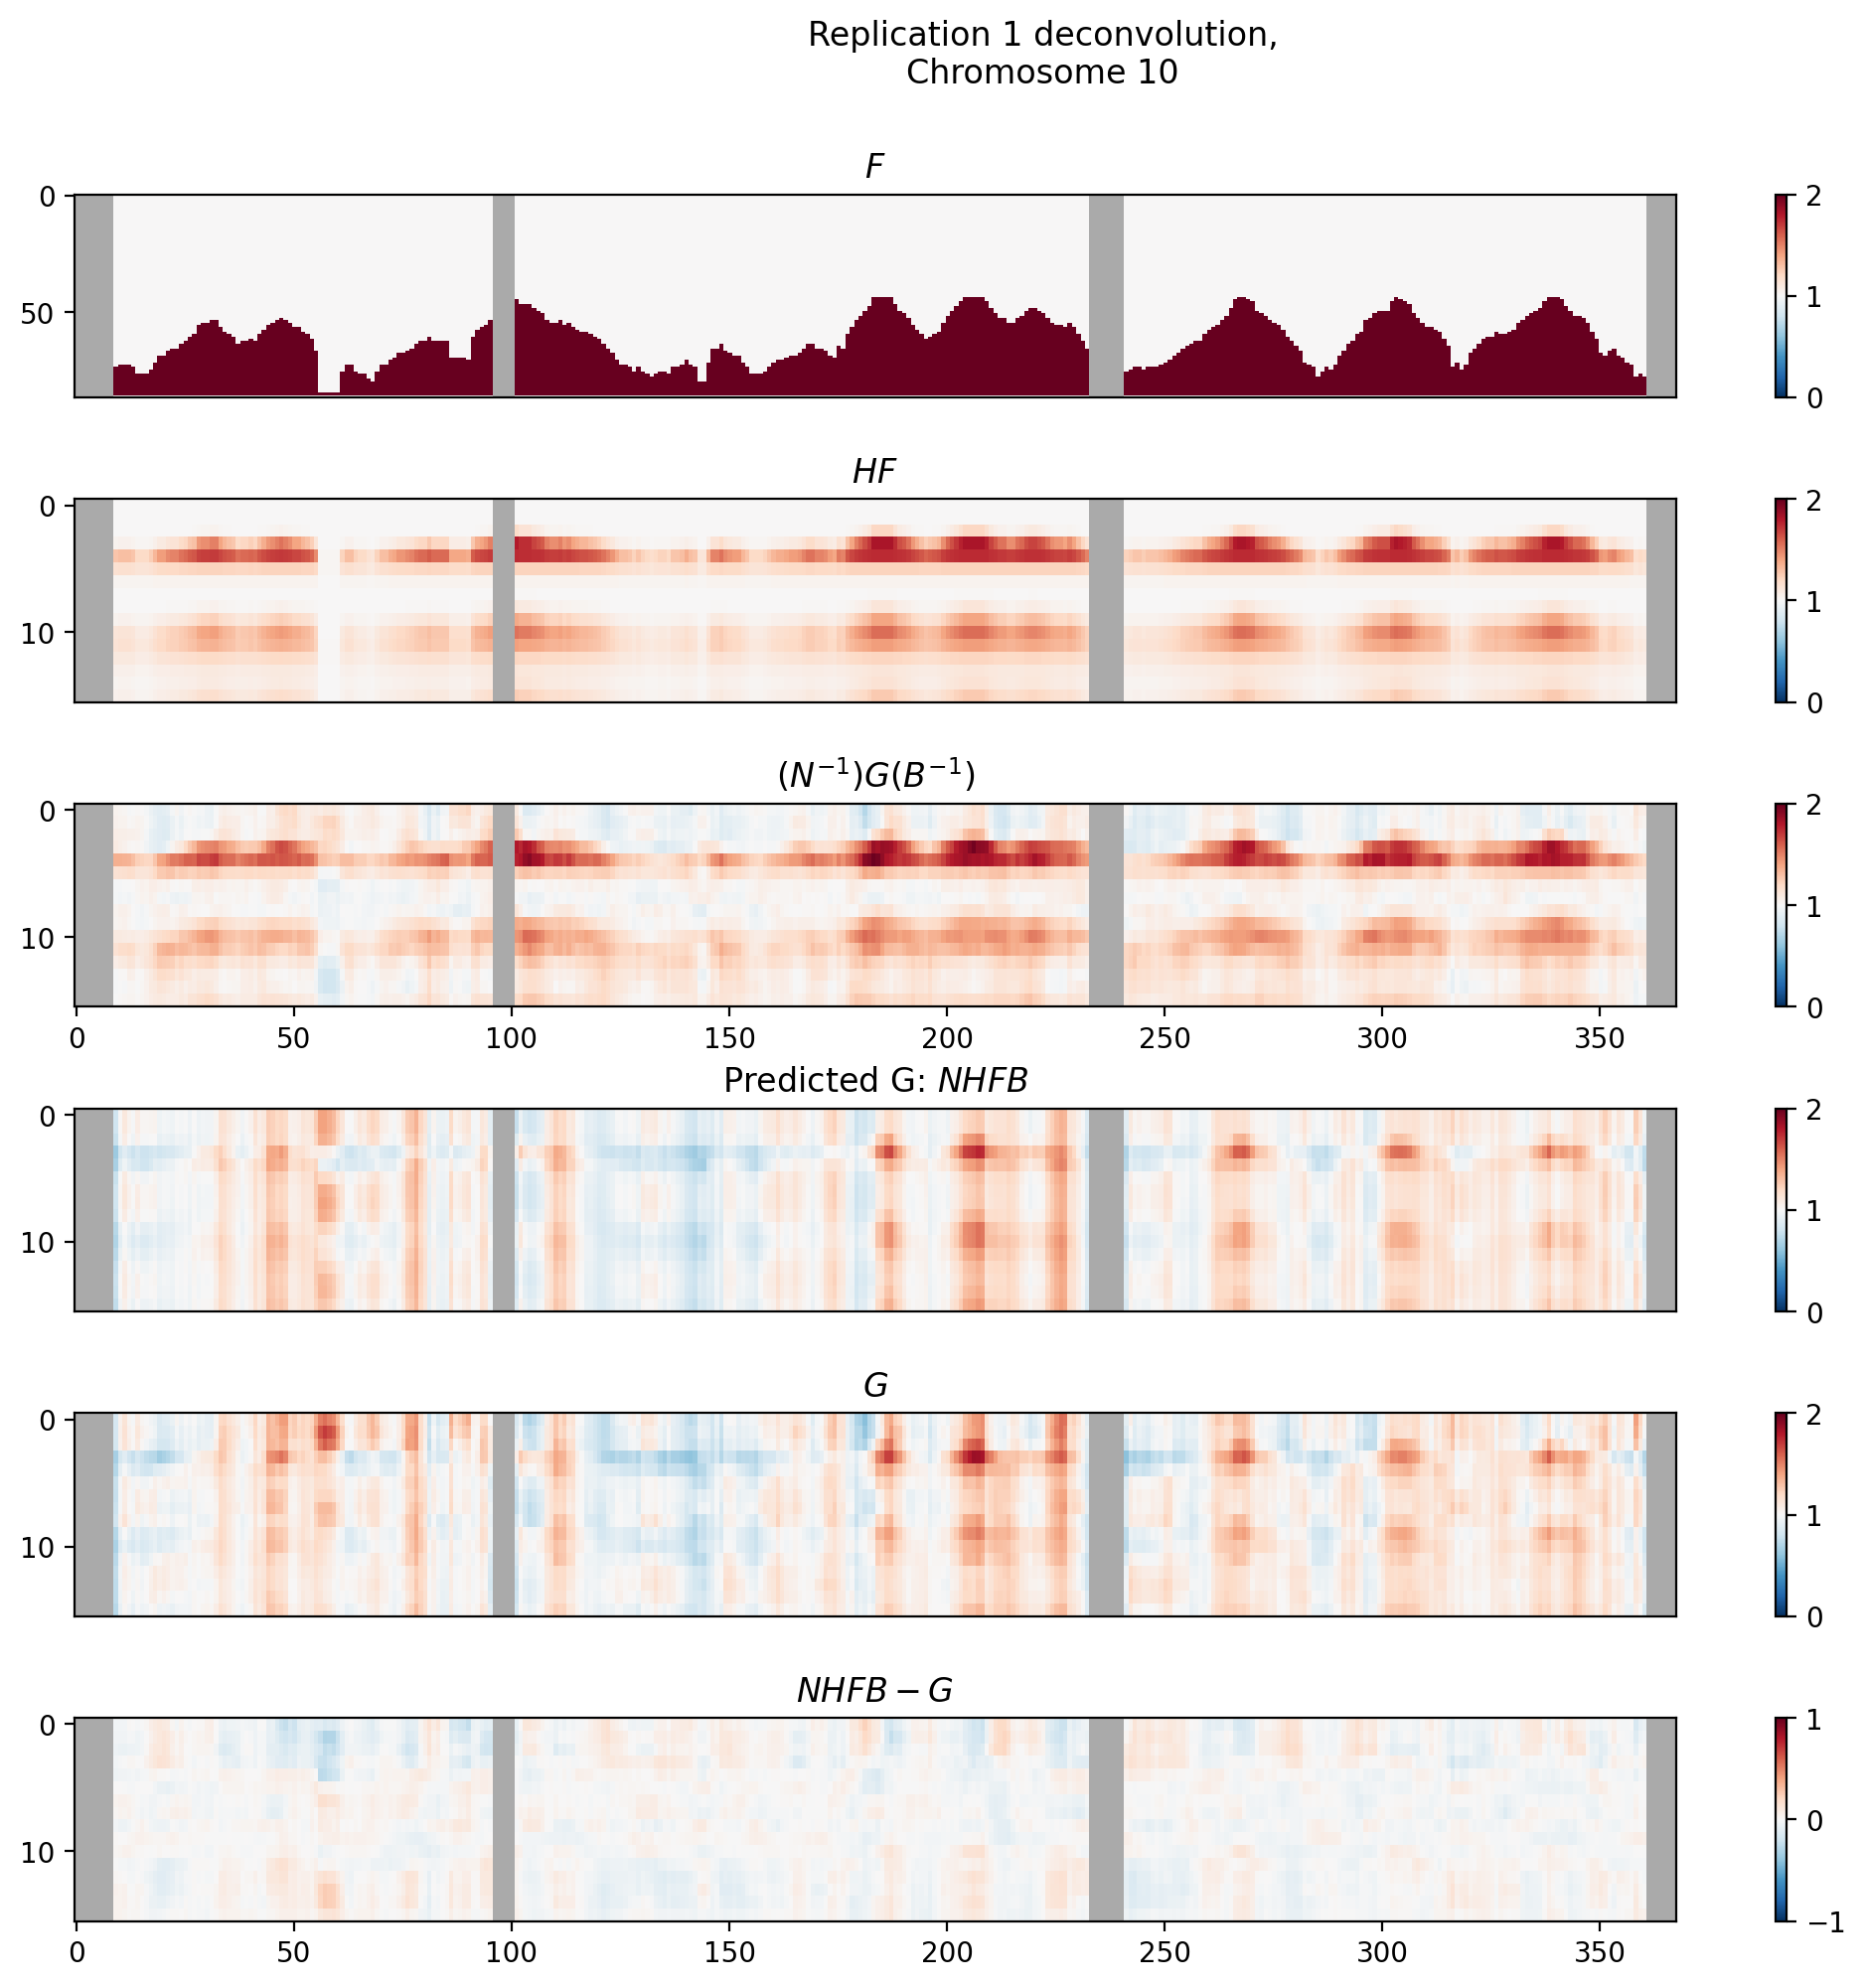

In [391]:
real_deconv1.plot_heatmaps()

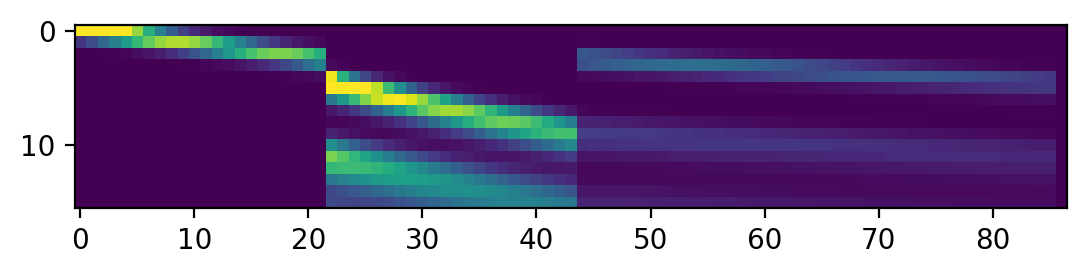

In [392]:
plt.imshow(real_deconv1.config.H, vmax=0.1)


In [475]:

def create_gamma2_search_space(params, size=5):
    gamma1, gamma2 = params['gamma1'], params['gamma2']

    s_length_prop = gamma2-gamma1
    gamma2_values = np.linspace(s_length_prop, 1., size)

    gamma_values_df = pd.DataFrame({'gamma2': gamma2_values})
    gamma_values_df['gamma1'] = gamma_values_df['gamma2'] - s_length_prop
    gamma_values_df = gamma_values_df[['gamma1', 'gamma2']]
    gamma_values_df['gamma_delta'] = 1-gamma2_values
    return gamma_values_df

In [606]:
# Determine values of gamma2 to test for, we will limit the length of g2 to the length
# of gamma2-gamma1 for now.

# This is a proof of concept that we can indeed use these genes to estimate this process.
num_search = 10
starting_parameters = real_deconv1.config.params_dic.copy()
gamma_deltas_df = create_gamma2_search_space(starting_parameters, num_search)

In [661]:
Hs = np.zeros((num_search, *real_deconv1.H.shape))
configs = []

for i, row in gamma_deltas_df.iterrows():

    # Reinitialize starting config parameters
    # For storage of indices later
    config, _ = load_default_chrom_configs()
    real_deconv1.config = config
    
    gamma_delta = row.gamma_delta
    updated_params = create_updated_params_from_gamma_delta(starting_parameters, gamma_delta)
    
    # Update the parameters and H
    real_deconv1.update_parameters(updated_params)
    updated_H = real_deconv1.config.H

    Hs[i] = updated_H
    configs.append(config)


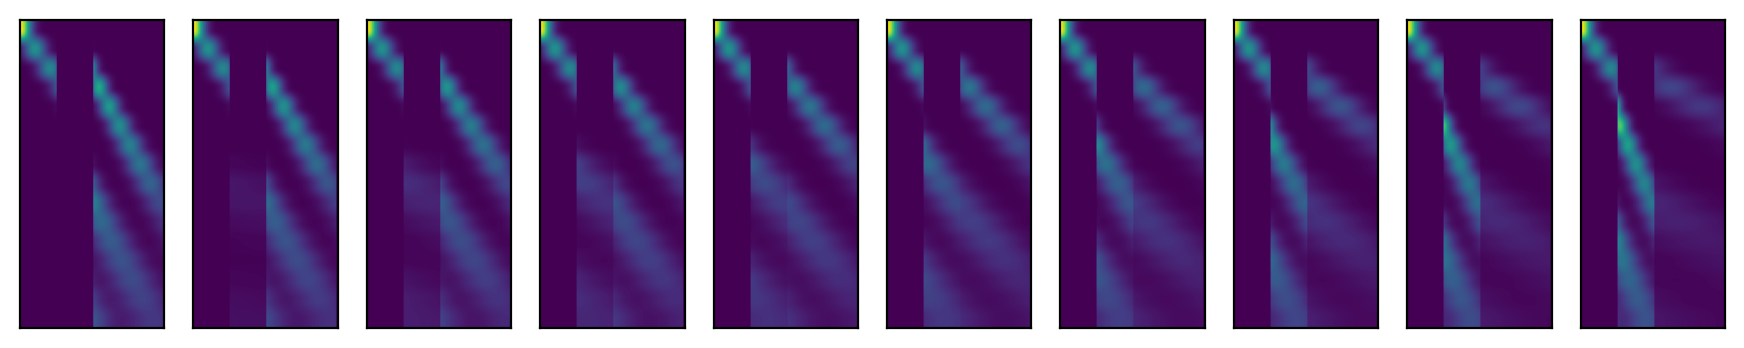

In [662]:
plt.figure(figsize=(11, 2))
for i in range(Hs.shape[0]):
    plt.subplot(1, num_search, i+1)
    plt.imshow(Hs[i], aspect='auto')
    plt.xticks([])
    plt.yticks([])


In [663]:
from src.model import Model
from src.config import load_combined_gene_expression_by_config_type
from src.config import read_yl_vst_data_rep

gene_expression_data_rep1 = read_yl_vst_data_rep(1)


In [666]:
def retrieve_gamma_search_fs(gene_name, Hs, gamma_values_df,
                            plot=False):
    fs = np.zeros((num_search, Hs.shape[2]))
    for i in range(Hs.shape[0]):
        gene_deconv_model = Model(configs[i], gene_name, expression_data=gene_expression_data_rep1)
        gene_deconv_model.H = Hs[i]
        gene_deconv_model.deconvolve_find_optimal_gamma()    

        if plot:
            fig = gene_deconv_model.plot_deconvolved_gene()
            plt.suptitle(f"{gene_name}, $\\gamma={gene_deconv_model.gamma}$,"
                     f"\n$\\gamma1,\\gamma2=[{gamma_values_df.iloc[0].gamma1:.2f}, "
                     f"{gamma_values_df.iloc[0].gamma2:.2f}$]", fontsize=24)
        f = gene_deconv_model.f
        fs[i] = f
    return fs

In [667]:
from src.timer import Timer
timer = Timer()

gene_names = ['CLN1', 'CLN2', 'CLN3', 'CLB5', 'CLB6', 'CLB1', 'CLB3', 'CLB4', 'CLB2']
gene_fs = {}
for gene_name in gene_names:

    fs = retrieve_gamma_search_fs(gene_name, Hs, gamma_deltas_df)
    gene_fs[gene_name] = fs
    timer.print_time()

00:00:18.960
00:00:38.076
00:00:52.203
00:01:06.361
00:01:25.329
00:01:39.928
00:01:55.053
00:02:09.970
00:02:25.037


In [814]:
def retrieve_average_phase_tx(config, gene_f):

    g1_indices = config.get_Hpositions_for_phase('CG1')
    s_indices = config.get_Hpositions_for_phase('S')
    g2m_indices = config.get_Hpositions_for_phase('G2M')

    g1_tps = config.get_timepoints_for_phase('CG1')
    s_tps = config.get_timepoints_for_phase('S')
    g2m_tps = config.get_timepoints_for_phase('G2M')

    def compute_tx(gene_f, timepoints, indices):
        if len(timepoints) == 0: return 0, 0
        time_len = timepoints[-1]-timepoints[0]
        if time_len == 0: return 0, 0
        total_tx = gene_f[indices].sum()
        return total_tx, time_len

    total_g1, g1_len = compute_tx(gene_f, g1_tps, g1_indices)
    total_s, s_len = compute_tx(gene_f, s_tps, s_indices)
    total_g2m, g2m_len = compute_tx(gene_f, g2m_tps, g2m_indices)

    return total_g1, total_s, total_g2m, g1_len, s_len, g2m_len

In [815]:
rows = []
for i in range(len(gamma_deltas_df)):
    for gene in gene_names:
        ret = retrieve_average_phase_tx(configs[i], gene_fs[gene][i])
        total_g1, total_s, total_g2m, g1_len, s_len, g2m_len = ret

        row = {'delta_index': i, 
                   'gene': gene,
                   'total_g1': total_g1,
                   'total_s': total_s,
                   'total_g2m': total_g2m,
                   'g1_len': g1_len,
                   's_len': s_len,
                   'g2m_len': g2m_len,
              }
        rows.append(row)
total_gene_dfs = pd.DataFrame(rows).set_index(['gene', 'delta_index'])
total_gene_dfs

total_g1     total_s   total_g2m    g1_len      s_len  \
gene delta_index                                                            
CLN1 0              0.000000  178.635902  314.928296   0.00000  22.656149   
CLN2 0              0.000000  177.016781  310.736521   0.00000  22.656149   
CLN3 0              0.000000  141.550570  267.531851   0.00000  22.656149   
CLB5 0              0.000000  147.994371  285.976449   0.00000  22.656149   
CLB6 0              0.000000  123.119564  261.094499   0.00000  22.656149   
...                      ...         ...         ...       ...        ...   
     9            206.864265  353.384427    0.000000  42.94192  22.434491   
CLB1 9            247.037467  481.784965    0.000000  42.94192  22.434491   
CLB3 9            229.933614  445.257673    0.000000  42.94192  22.434491   
CLB4 9            209.135686  411.894448    0.000000  42.94192  22.434491   
CLB2 9            253.265198  481.454261    0.000000  42.94192  22.434491   

                    g2m_len  
gene delta_index             
CLN1 0            42.075706  
CLN2 0            42.075706  
CLN3 0            42.075706  
CLB5 0            42.075706  
CLB6 0            42.075706  
...                     ...  
     9             0.000000  
CLB1 9             0.000000  
CLB3 9             0.000000  
CLB4 9             0.000000  
CLB2 9             0.000000  

[90 rows x 6 columns]

In [890]:
def plot_gamma_delta_set(gamma_deltas_df, index):
    
    config = configs[index]
    t_branch_indices = config.get_Hpositions_for_branch('t')
    t_branch_tps = config.get_timepoints_for_branch('t')
    from src.chromatin_model import draw_phase_label_annotations

    def plot_genes_group(plot_genes):
        for plot_gene in plot_genes:
            gene_f = gene_fs[plot_gene][index]
            plt.plot(t_branch_tps, gene_f[t_branch_indices], label=plot_gene)
        draw_phase_label_annotations(plt.gca(), config, flip=True)            
        plt.legend()

    plt.figure(figsize=(13, 3))

    plt.subplot(1, 3, 1)
    plot_genes_group(['CLN1', 'CLN2', 'CLN3'])
    plt.title("G1 cyclins")

    plt.subplot(1, 3, 2)
    plot_genes_group(['CLB5', 'CLB6'])
    plt.title("S cyclins")

    plt.subplot(1, 3, 3)
    plot_genes_group(['CLB1', 'CLB3', 'CLB4', 'CLB2'])
    plt.title("M cyclins")
    
    row = gamma_deltas_df.loc[index]
    plt.suptitle(f"S-phase: $\\gamma_1-\\gamma_2$, {row.gamma1:.1f}-{row.gamma2:.1f}")
    plt.subplots_adjust(top=0.8)

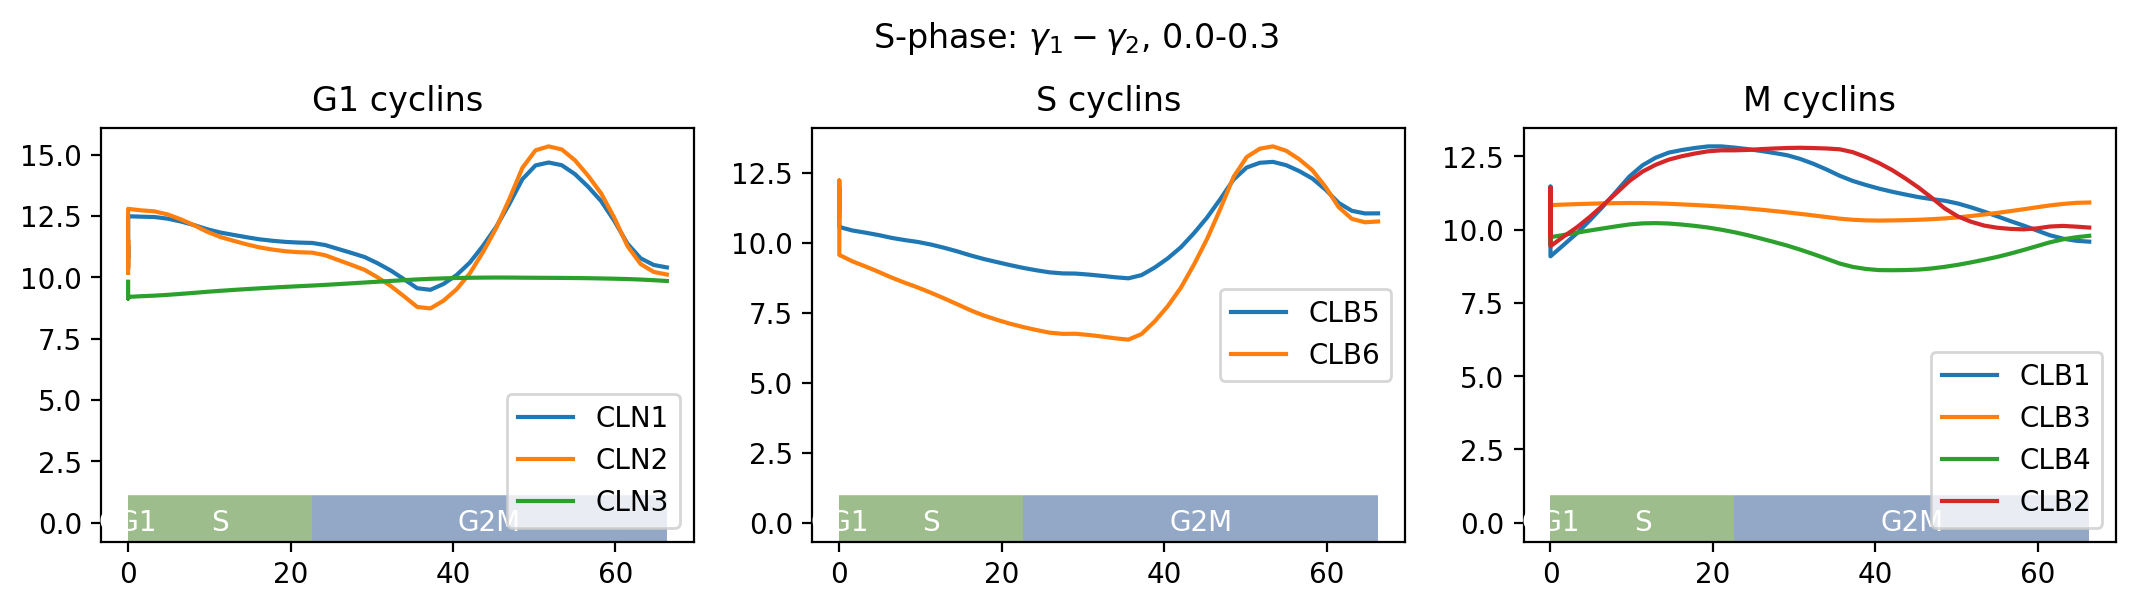

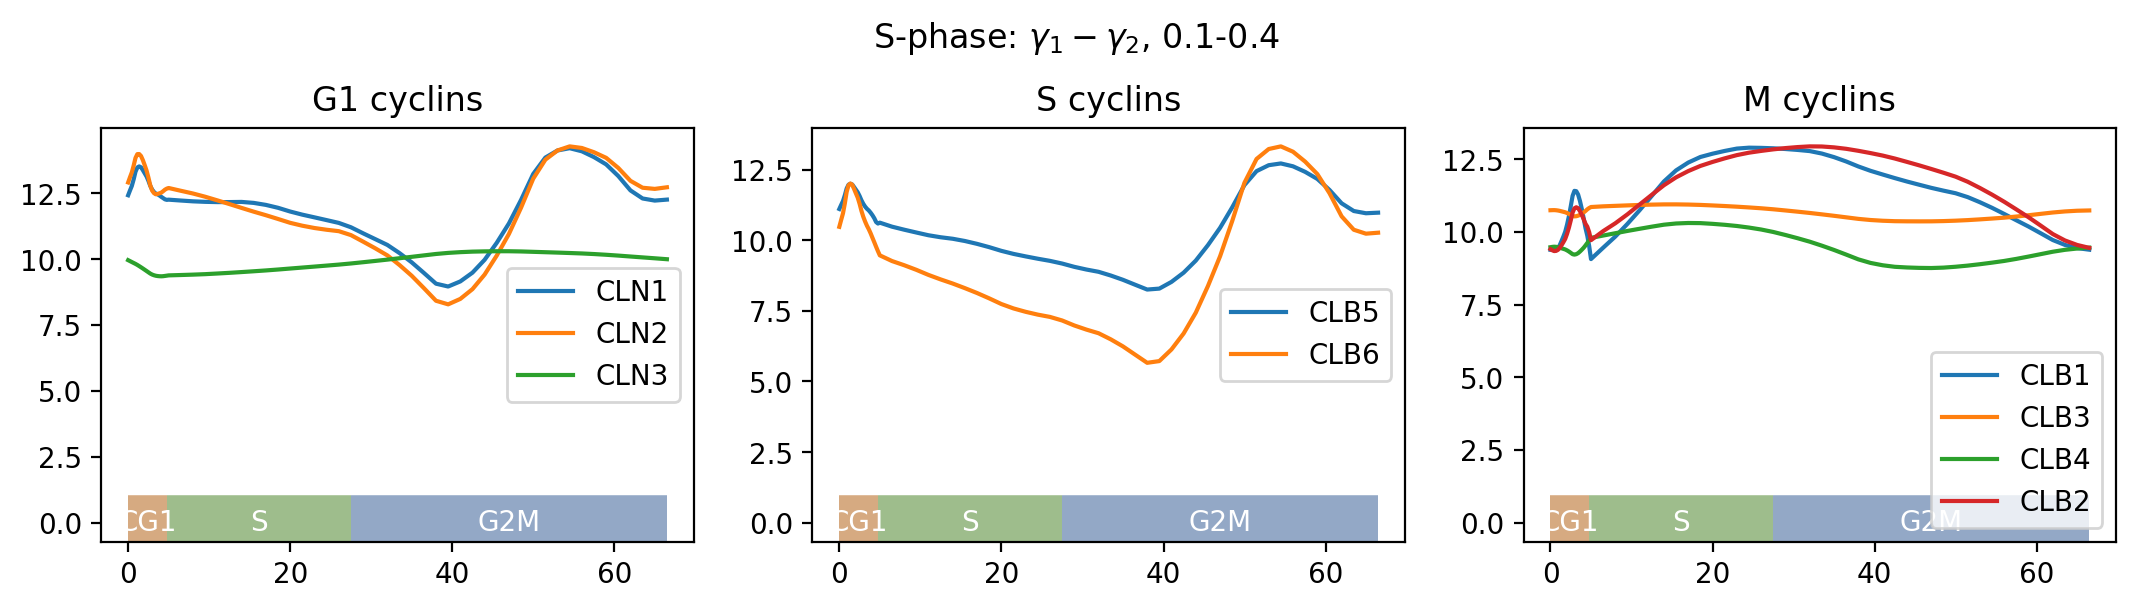

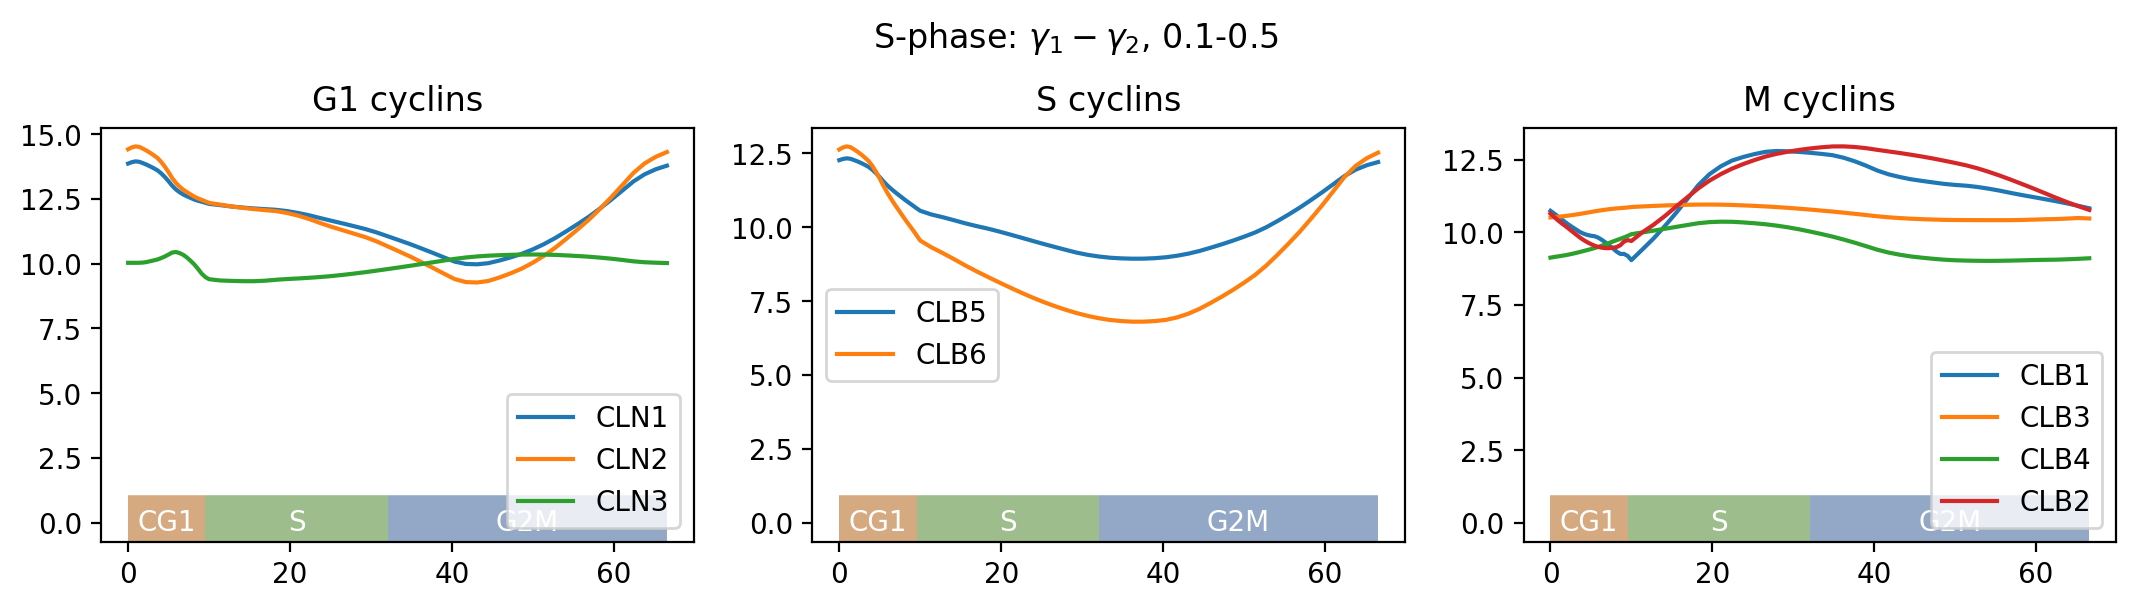

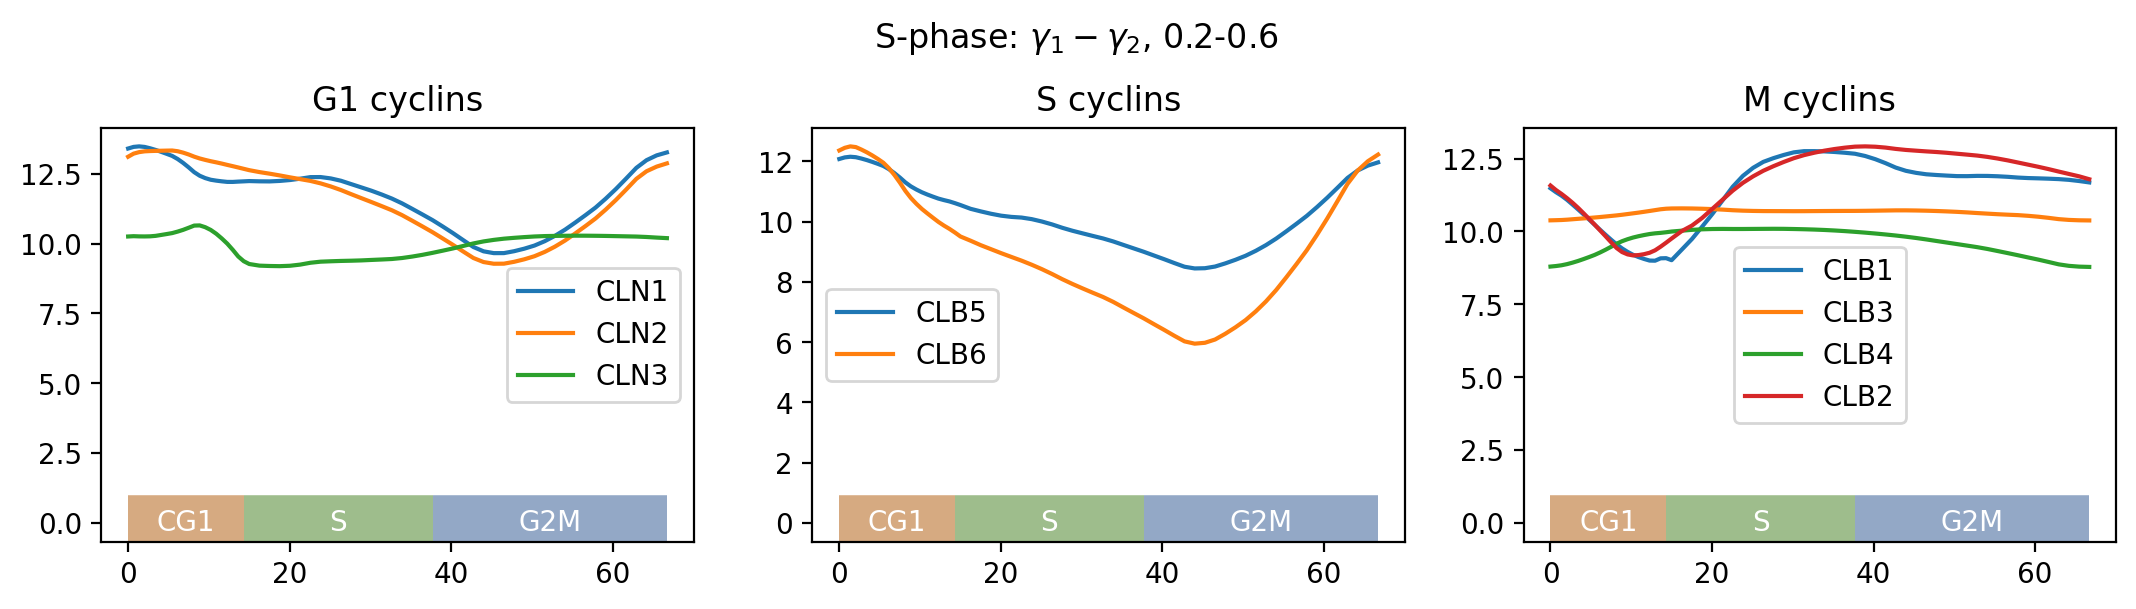

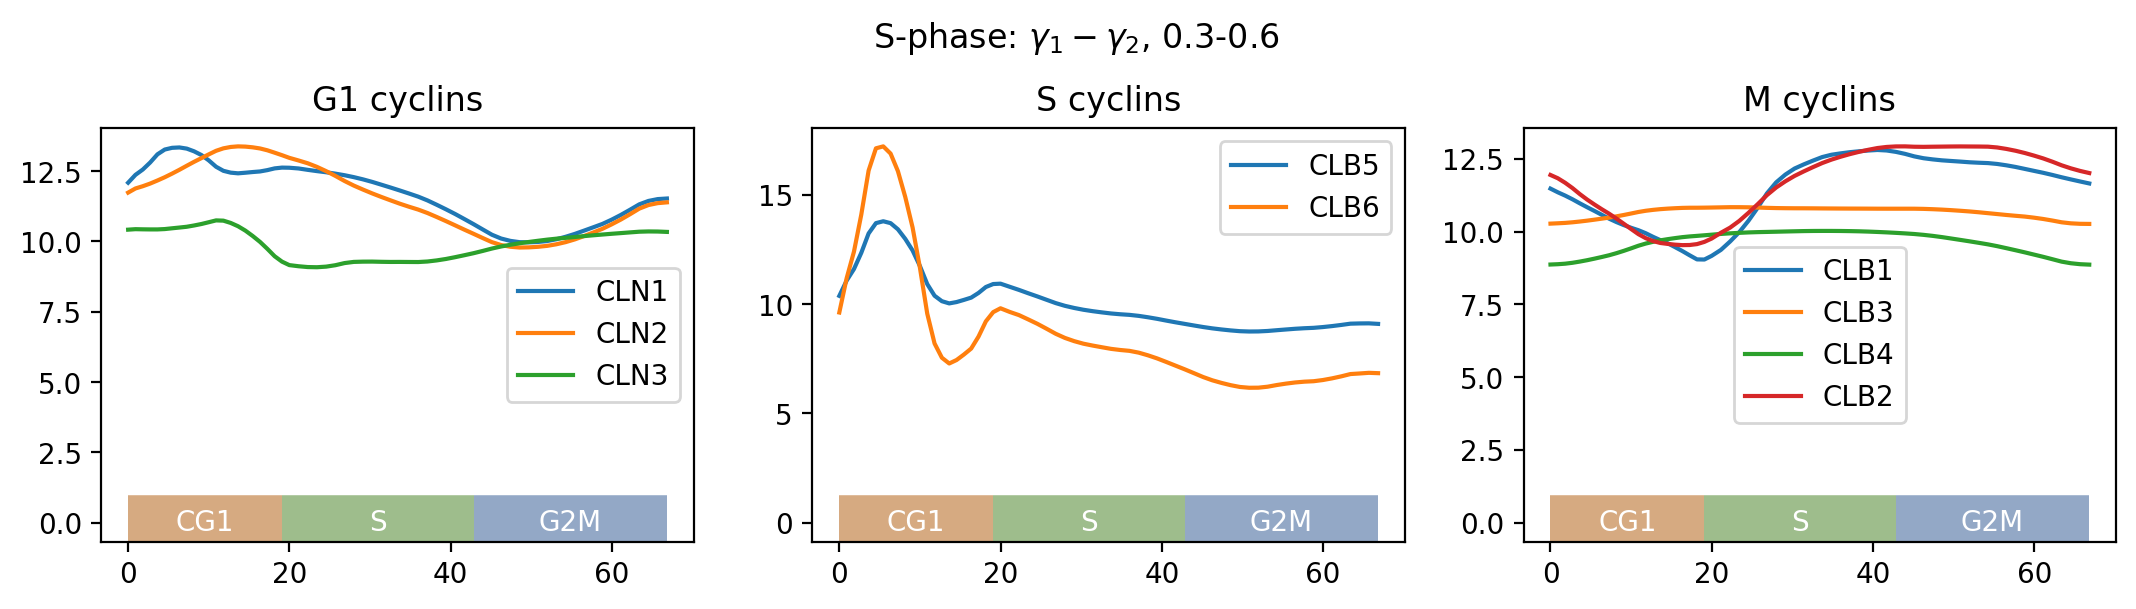

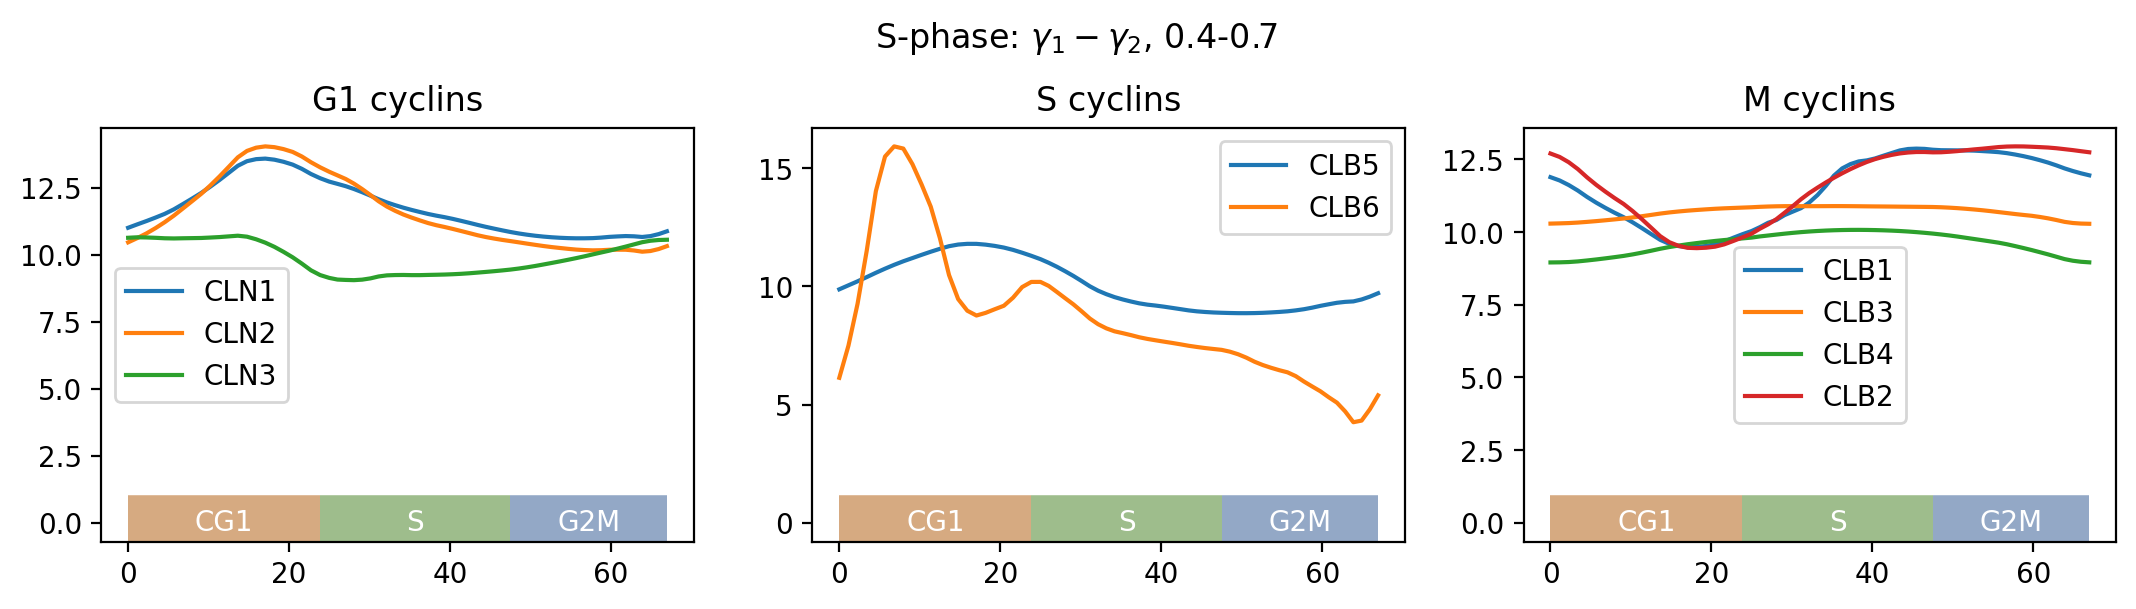

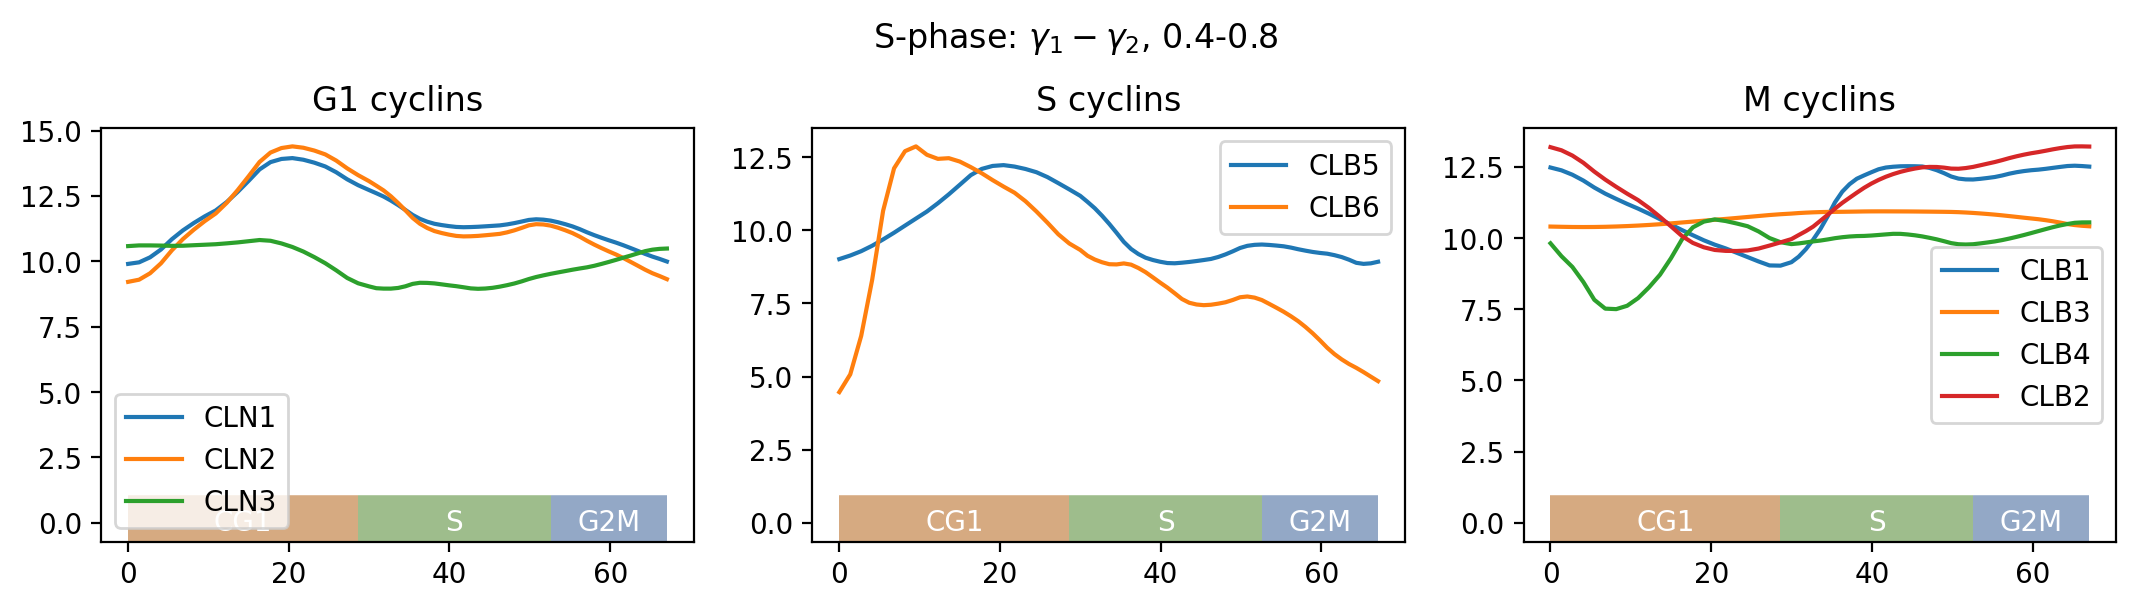

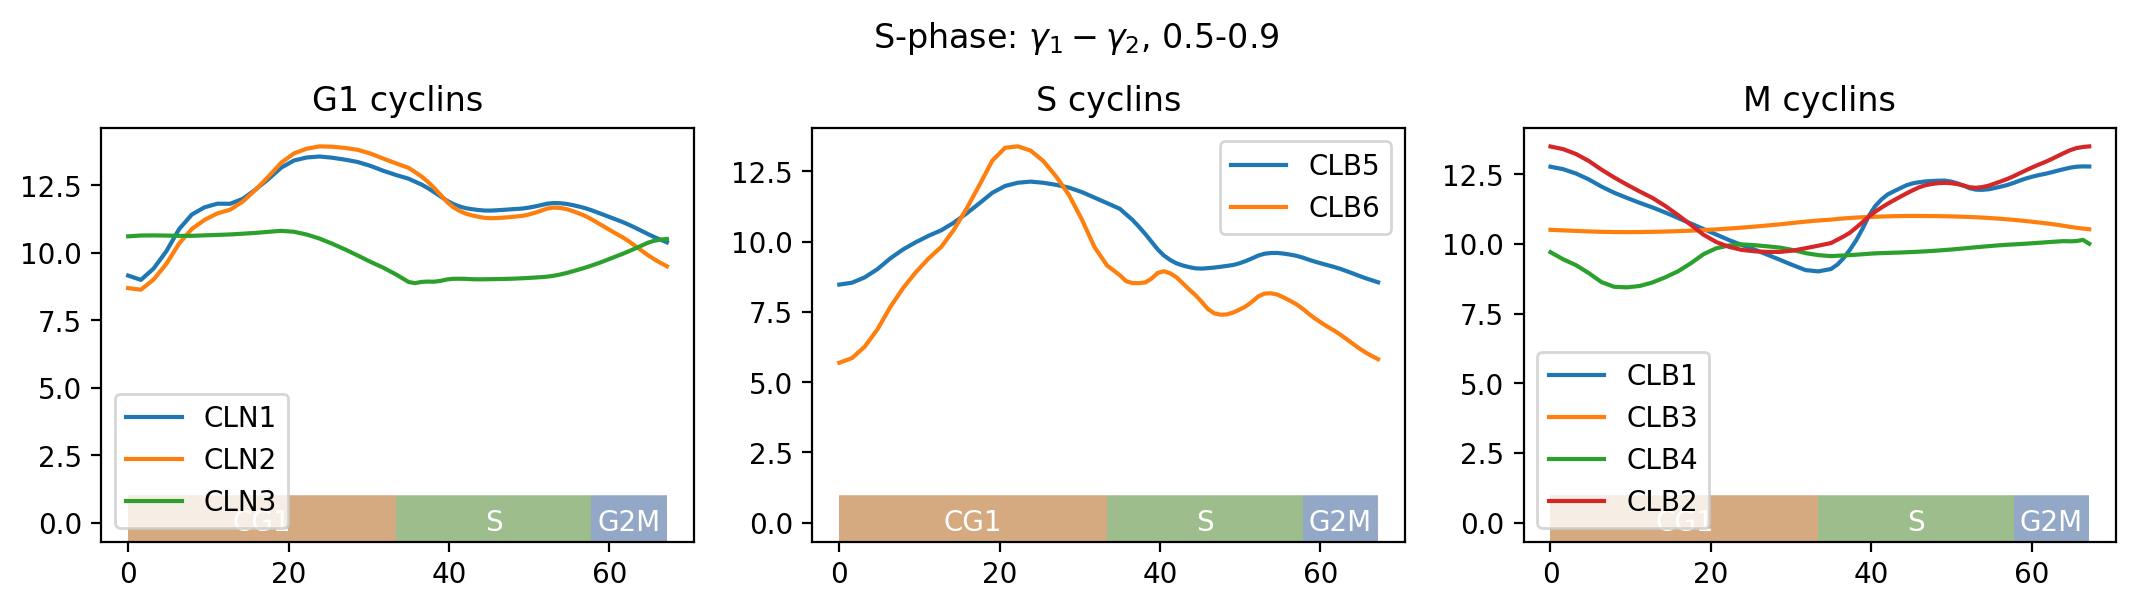

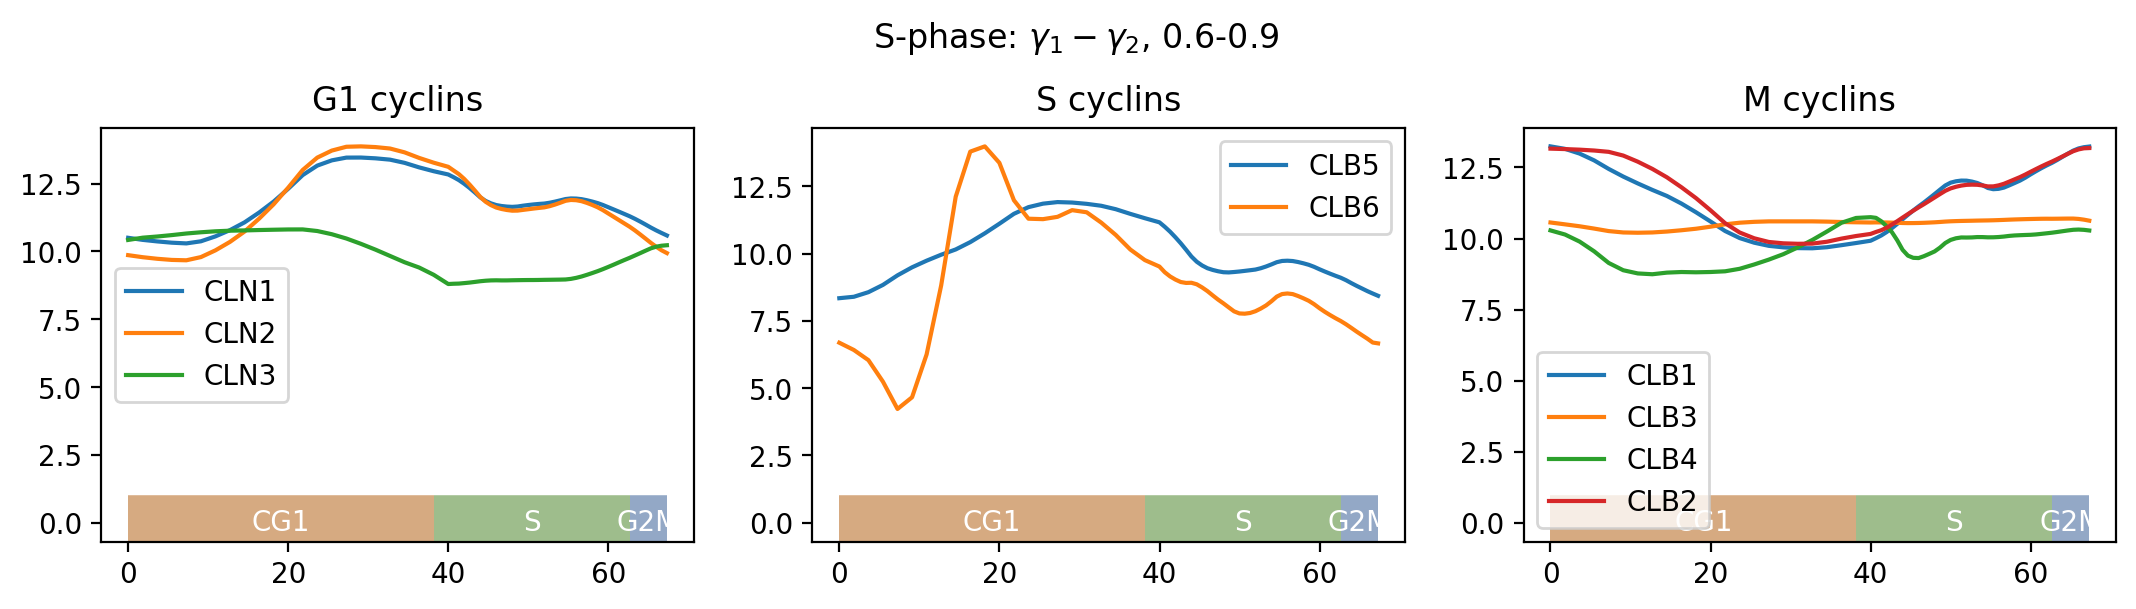

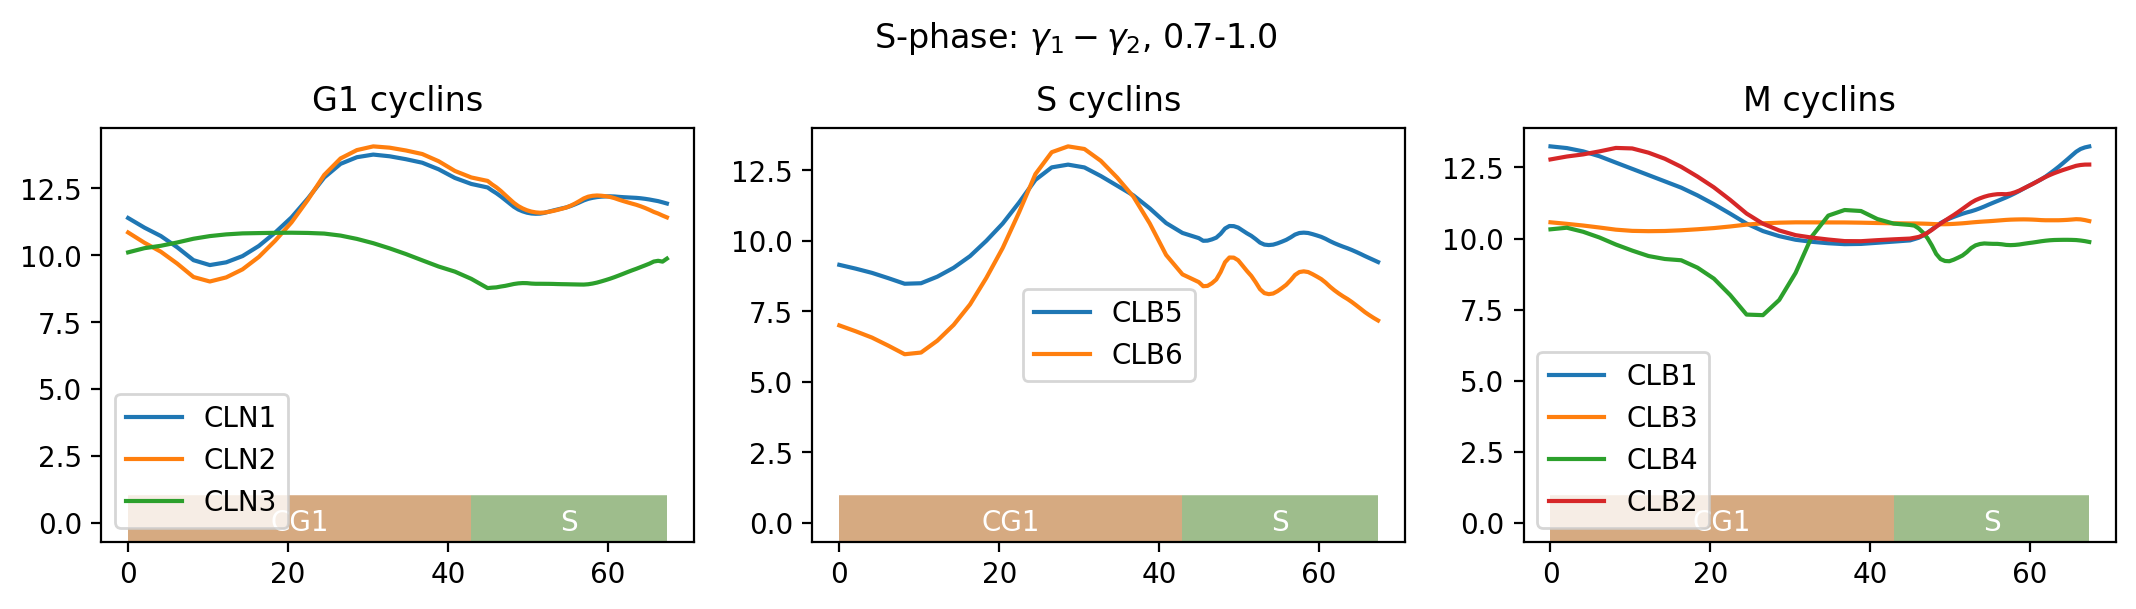

In [891]:

for i in range(len(gamma_deltas_df)):
    plot_gamma_delta_set(gamma_deltas_df, i)


In [825]:
total_gene_dfs['total_expression'] = total_gene_dfs['total_g1']+\
    total_gene_dfs['total_s']+total_gene_dfs['total_g2m']

total_gene_dfs['proportion_g1'] = total_gene_dfs['total_g1']/total_gene_dfs['total_expression']
total_gene_dfs['proportion_s'] = total_gene_dfs['total_s']/total_gene_dfs['total_expression']
total_gene_dfs['proportion_g2m'] = total_gene_dfs['total_g2m']/total_gene_dfs['total_expression']

Text(0, 0.5, 'Proportion of total expression')

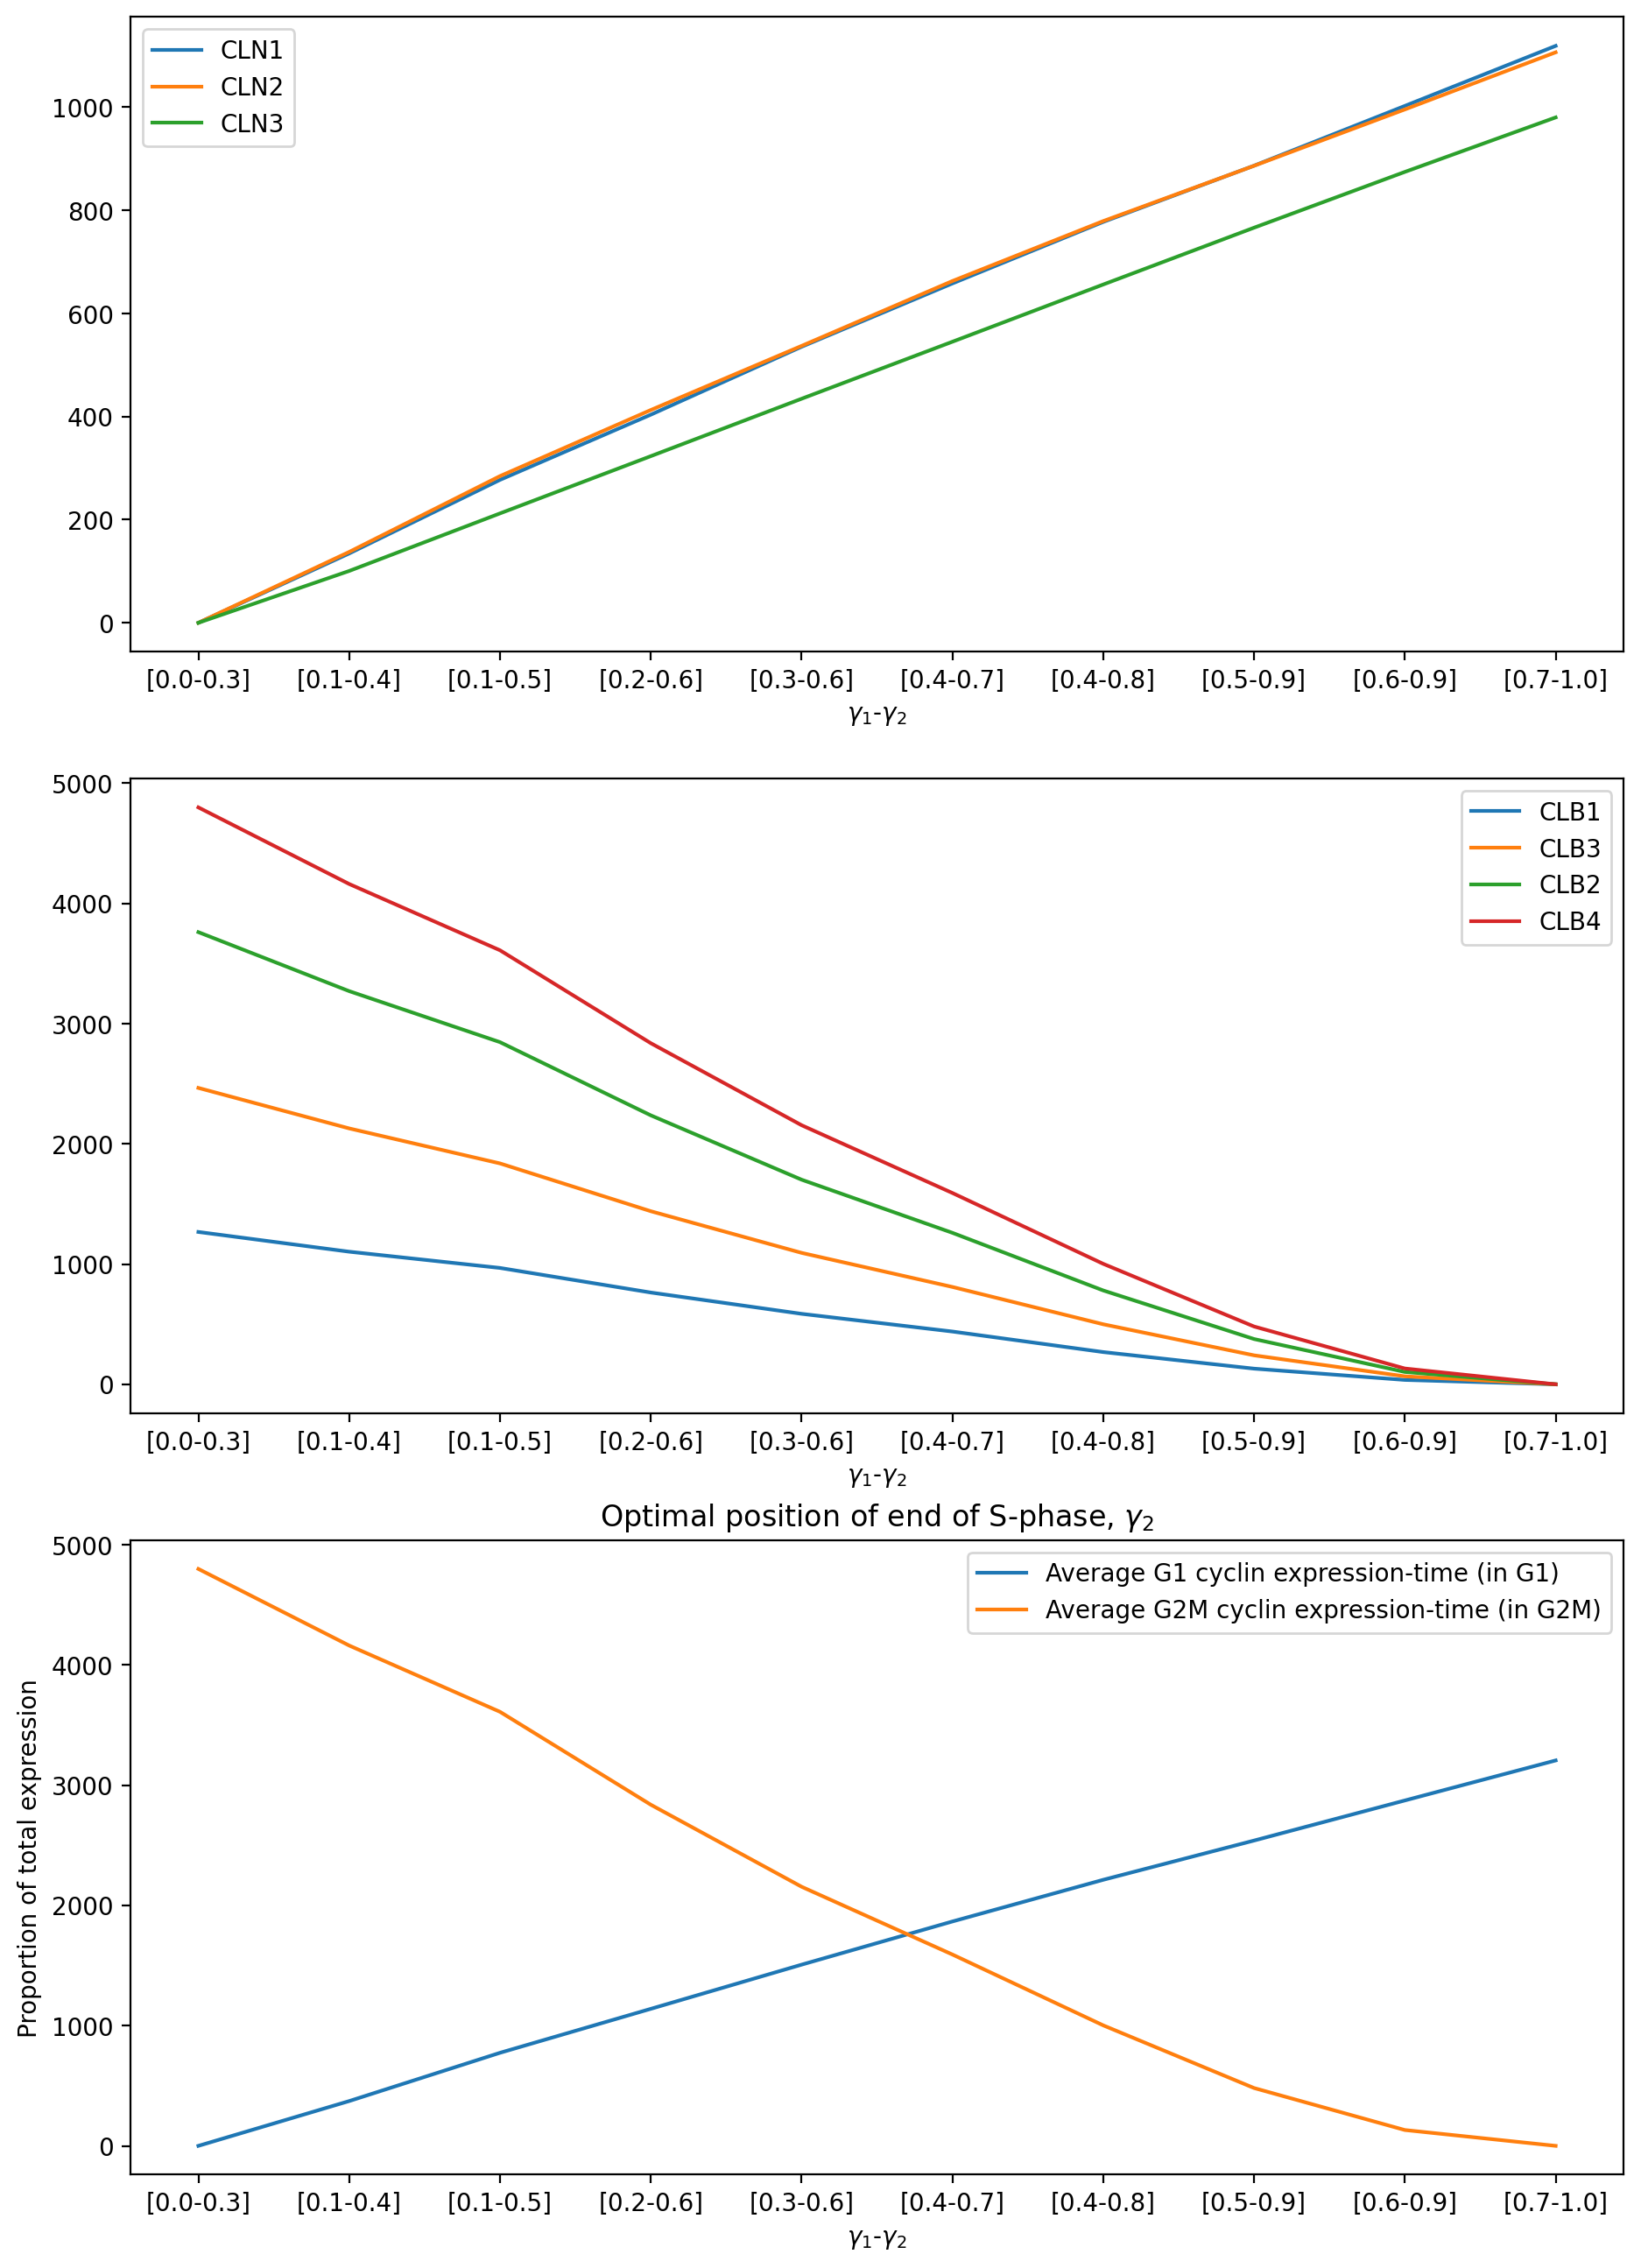

In [946]:
g1_color = plt.cm.tab10(0)
g2m_color = plt.cm.tab10(1)

subset_of_deltas = np.arange(0, len(gamma_deltas_df))
gamma1 = gamma_deltas_df['gamma1'].iloc[subset_of_deltas]
gamma2 = gamma_deltas_df['gamma2'].iloc[subset_of_deltas]
x_labels = [f"[{s1:.1f}-{s2:.1f}]" for s1, s2 in list(zip(gamma1.values, gamma2.values))]

g1_genes = ['CLN1', 'CLN2', 'CLN3']
g2m_genes = ['CLB1', 'CLB3', 'CLB2', 'CLB4']

average_g1_cyclin_expression_time = np.zeros(len(subset_of_deltas))
average_g2m_cyclin_expression_time = np.zeros(len(subset_of_deltas))

fig = plt.figure(figsize=(11, 16))

plt.subplot(3, 1, 1)
for g1_gene in g1_genes:
    gene_expression = total_gene_dfs.loc[g1_gene].iloc[subset_of_deltas].total_g1
    g1_length = total_gene_dfs.loc[g1_gene].iloc[subset_of_deltas].g1_len
    avg_expression_time = gene_expression*g1_length/len(subset_of_deltas)
    average_g1_cyclin_expression_time += avg_expression_time
    plt.plot(x_labels, avg_expression_time, label=g1_gene)

plt.legend()
plt.xlabel("$\\gamma_1$-$\\gamma_2$")

plt.subplot(3, 1, 2)
for g2m_gene in g2m_genes:
    gene_expression = total_gene_dfs.loc[g2m_gene].iloc[subset_of_deltas].total_g2m
    g2m_length = total_gene_dfs.loc[g2m_gene].iloc[subset_of_deltas].g2m_len
    avg_expression_time = gene_expression*g2m_length/(len(subset_of_deltas))
    average_g2m_cyclin_expression_time += avg_expression_time
    plt.plot(x_labels, average_g2m_cyclin_expression_time, label=g2m_gene)

plt.legend()
plt.xlabel("$\\gamma_1$-$\\gamma_2$")

plt.subplot(3, 1, 3)
plt.plot(x_labels, average_g1_cyclin_expression_time,
    label="Average G1 cyclin expression-time (in G1)")
plt.plot(x_labels, average_g2m_cyclin_expression_time,
    label="Average G2M cyclin expression-time (in G2M)")
plt.legend()
plt.title("Optimal position of end of S-phase, $\\gamma_2$")
plt.xlabel("$\\gamma_1$-$\\gamma_2$")
plt.ylabel("Proportion of total expression")
